# Baseline Comparison : Figure S10

In [1]:
import numpy as np
import pandas as pd
from suppl_baseline_functions import *

DRUG_DATA_PATH = '../../data/baseline_analysis/drug_data/level3_control_expdata_lm.tsv'
CELL_INFO_PATH = '../../data/baseline_analysis/drug_data/GSE92742_Broad_LINCS_cell_info.txt'
RNASEQ_DIR = '../../data/baseline_analysis/RNA/'
MICRO_DIR = '../../data/baseline_analysis/Micro/'
RNA_META_PATH = '../../data/RNAseq_data_forDE/clean_TB_sample_metadata_classification.tsv'
MICRO_META_PATH = '../../data/RNAseq_data_forDE/clean_TB_sample_metadata_classification.tsv'
GENE_INFO_PATH = '../../data/metadata/Homo_sapiens.gene_info.tsv'
CORRELATION_TYPES = ['pearson', 'spearman', 'rbo', 'lasso']

## Calculate correlations

In [3]:
# Load & preprocess drug data
drug_data_raw, split_drug = load_drug_data(DRUG_DATA_PATH)
drug_data_avg  = average_replicates(drug_data_raw, split_drug)
drug_data_qn   = quantile_normalize(drug_data_avg)
drug_data_cell = stouffer_aggregate(drug_data_qn)   # genes × cell lines

landmark_genes = drug_data_raw.index

# Build drug tissue groups
cell_line_info    = pd.read_csv(CELL_INFO_PATH, sep='\t', index_col='cell_id')
cell_line_tissues = cell_line_info['primary_site'].to_dict()

# Keep only cell lines present in our aggregated data
cell_line_tissue_series = pd.Series({
    cl: tissue
    for cl, tissue in cell_line_tissues.items()
    if cl in drug_data_cell.columns
})

drug_tissue_groups = build_tissue_groups(cell_line_tissue_series)
drug_tissues       = sorted(drug_tissue_groups.keys())

# Total original drug sample count per tissue (for informative axis labels)
cell_line_counts = split_drug['cell'].value_counts().to_dict()
drug_tissue_sample_counts = {
    tissue: sum(cell_line_counts.get(cl, 0) for cl in cls)
    for tissue, cls in drug_tissue_groups.items()
}

# Load & preprocess disease data
dis_data_qn, rnaseq_tissue, rnaseq_cell = load_disease_data(
    RNASEQ_DIR, MICRO_DIR, RNA_META_PATH, MICRO_META_PATH, GENE_INFO_PATH,
    landmark_genes,
    drug_data_cell.iloc[:, 0],          # reference distribution for QN
)

disease_tissue_groups = build_tissue_groups(rnaseq_tissue, min_count=10)
disease_tissues       = sorted(disease_tissue_groups.keys())

# Compute sample-level correlation matrices
# Subset both datasets to shared genes
shared_genes = drug_data_cell.index.intersection(dis_data_qn.index)
drug_subset  = drug_data_cell.loc[shared_genes]
dis_subset   = dis_data_qn.loc[shared_genes]

# Drug × disease  (rows = cell lines, cols = disease samples)
drug_dis_corrs = compute_correlation_matrix(drug_subset, dis_subset, CORRELATION_TYPES)

# Drug × drug     (rows = cell lines, cols = cell lines)
drug_drug_corrs = compute_correlation_matrix(
    drug_data_cell, drug_data_cell, CORRELATION_TYPES
)

# Save
for ctype, mat in drug_dis_corrs.items():
    mat.to_csv(f'drug_vs_disease_{ctype}.csv')
for ctype, mat in drug_drug_corrs.items():
    mat.to_csv(f'drug_vs_drug_{ctype}.csv')

In [4]:
[(tis, drug_tissue_groups[tis]) for tis in drug_tissues]

[('-666', ['NEU']),
 ('adipose', ['ASC']),
 ('blood', ['U266']),
 ('bone', ['CD34']),
 ('breast', ['BT20', 'HS578T', 'MCF10A', 'MCF7', 'MDAMB231', 'SKBR3']),
 ('central nervous system', ['NPC']),
 ('haematopoietic and lymphoid tissue',
  ['HL60', 'JURKAT', 'NOMO1', 'THP1', 'U937']),
 ('kidney', ['HA1E', 'HEK293T', 'NKDBA']),
 ('large intestine', ['HT29']),
 ('liver', ['HEPG2', 'HUH7', 'PHH']),
 ('lung', ['A549', 'HCC515']),
 ('muscle', ['SKB']),
 ('prostate', ['PC3', 'VCAP']),
 ('skin', ['A375', 'FIBRNPC'])]

## Plot Matrix Heatmaps

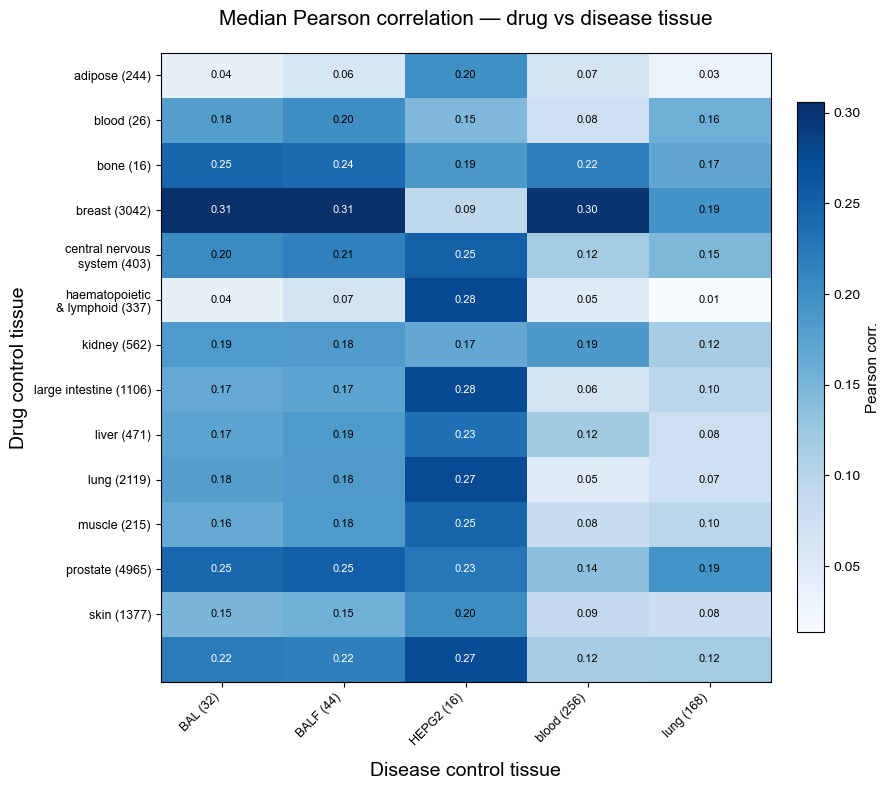

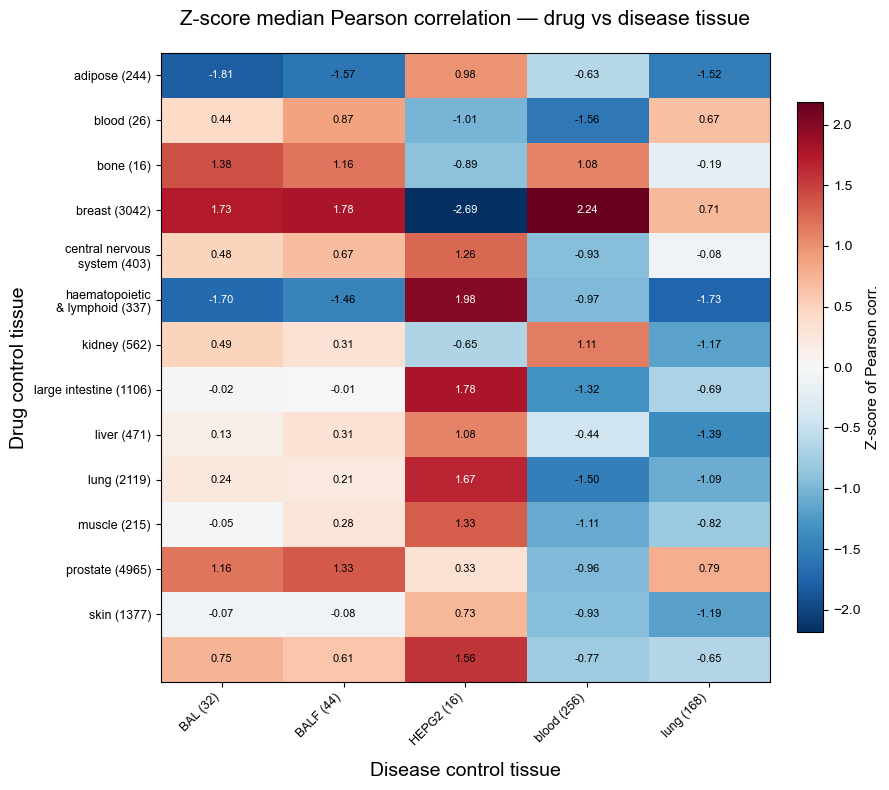

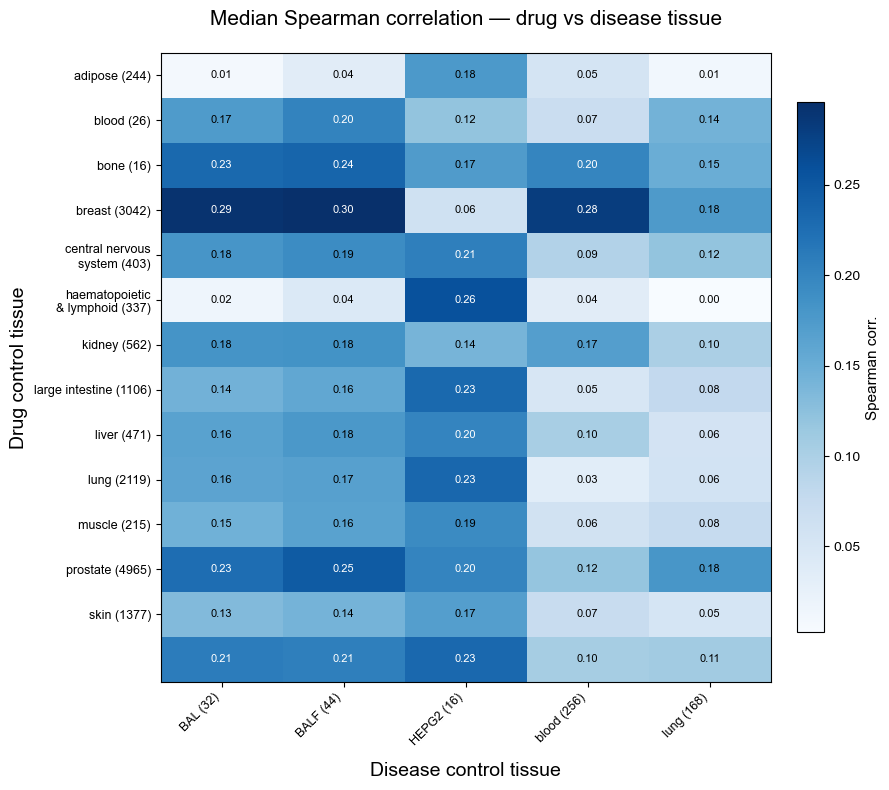

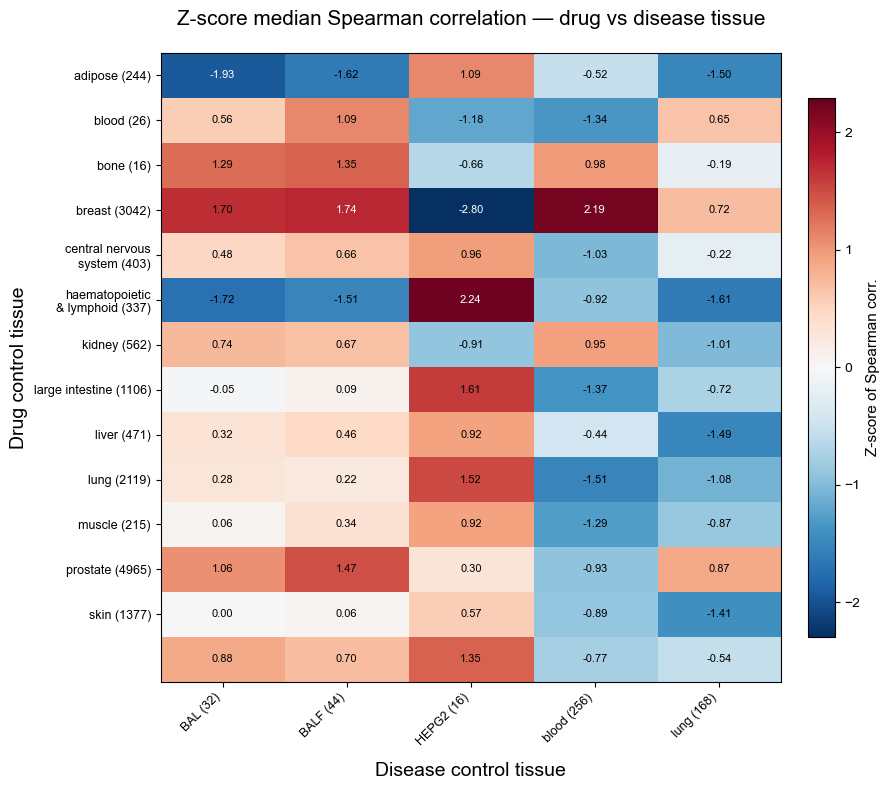

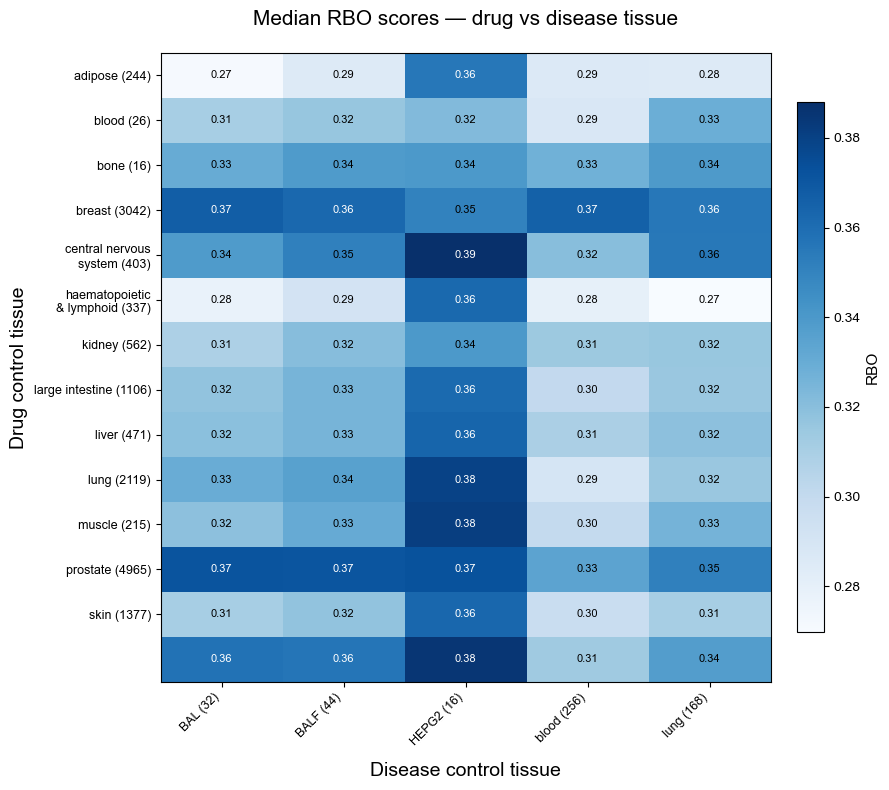

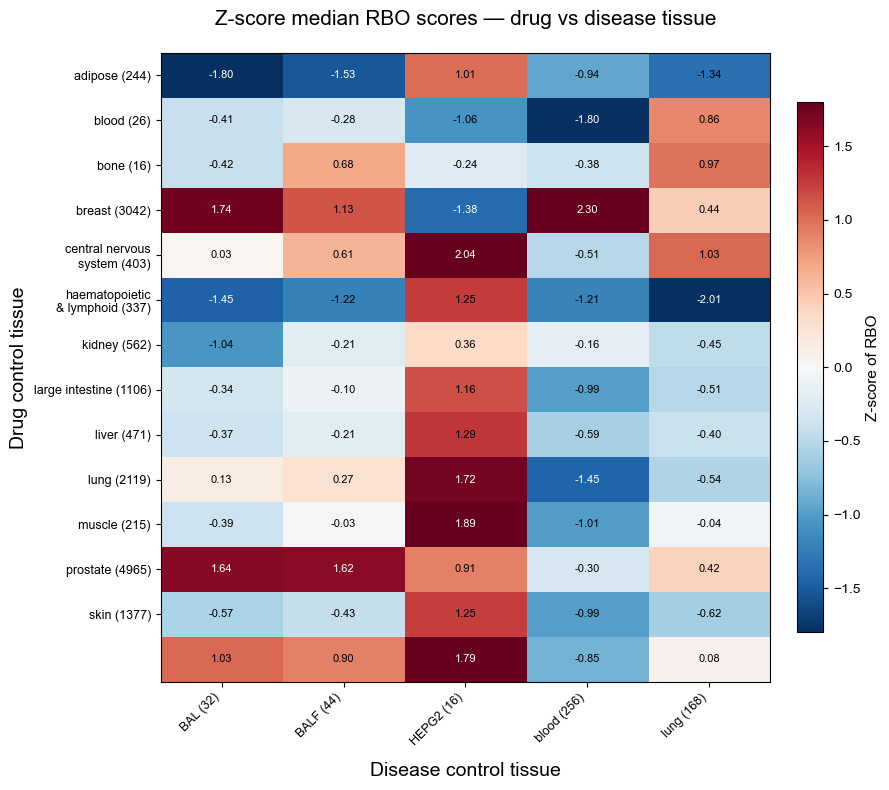

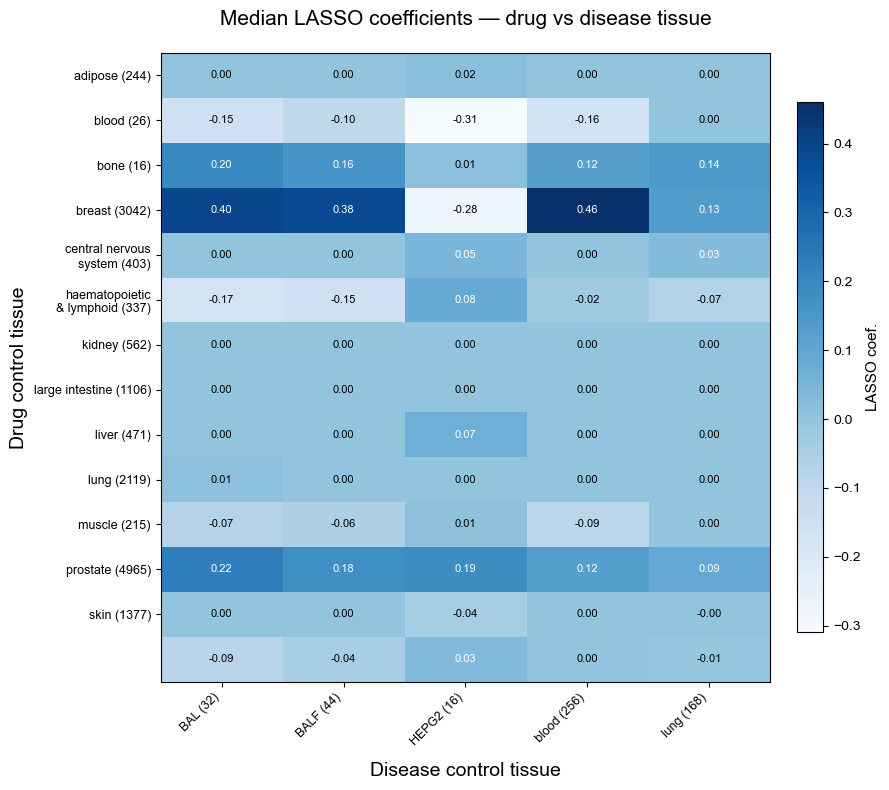

/Users/landon/integrative-drugrep-tb/figures/figureS9/suppl_baseline_functions.py:355: RuntimeWarning: invalid value encountered in divide
  return (matrix - mean) / std


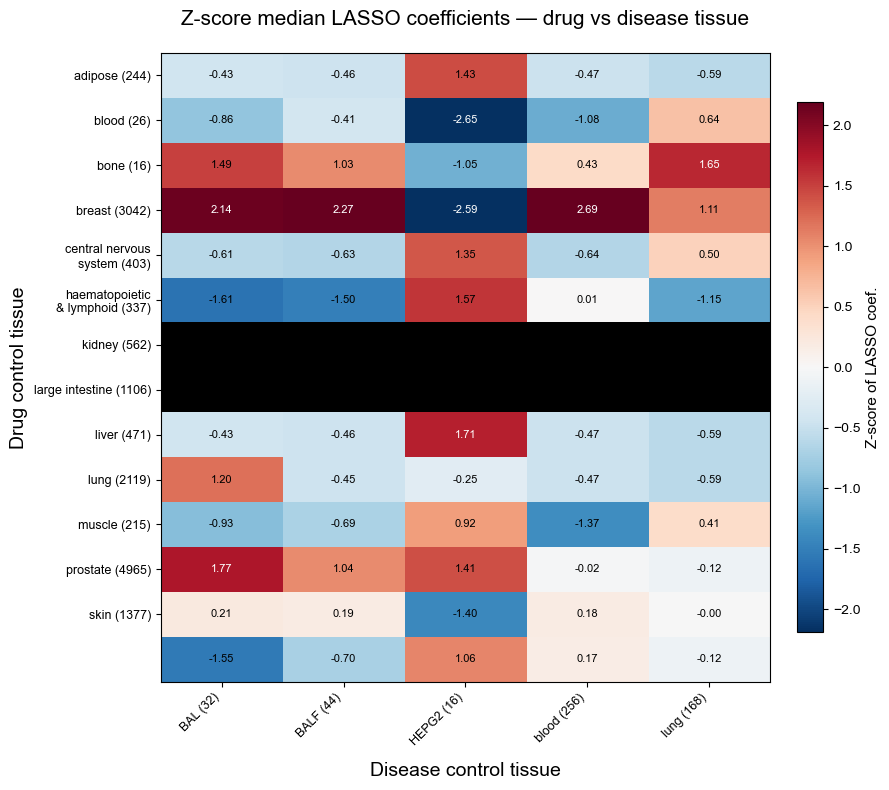

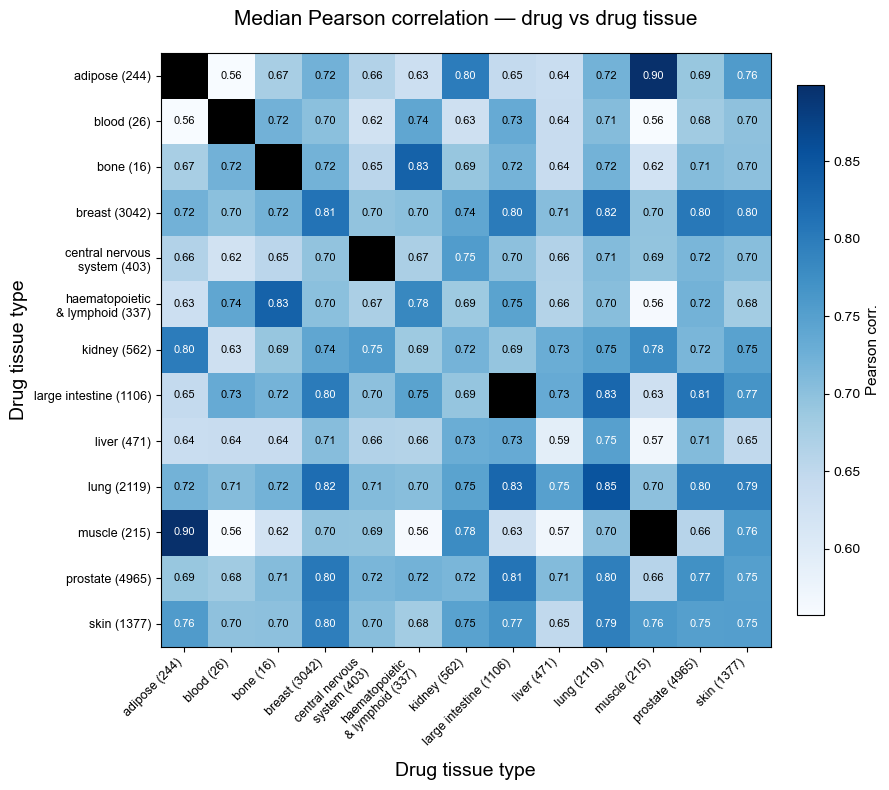

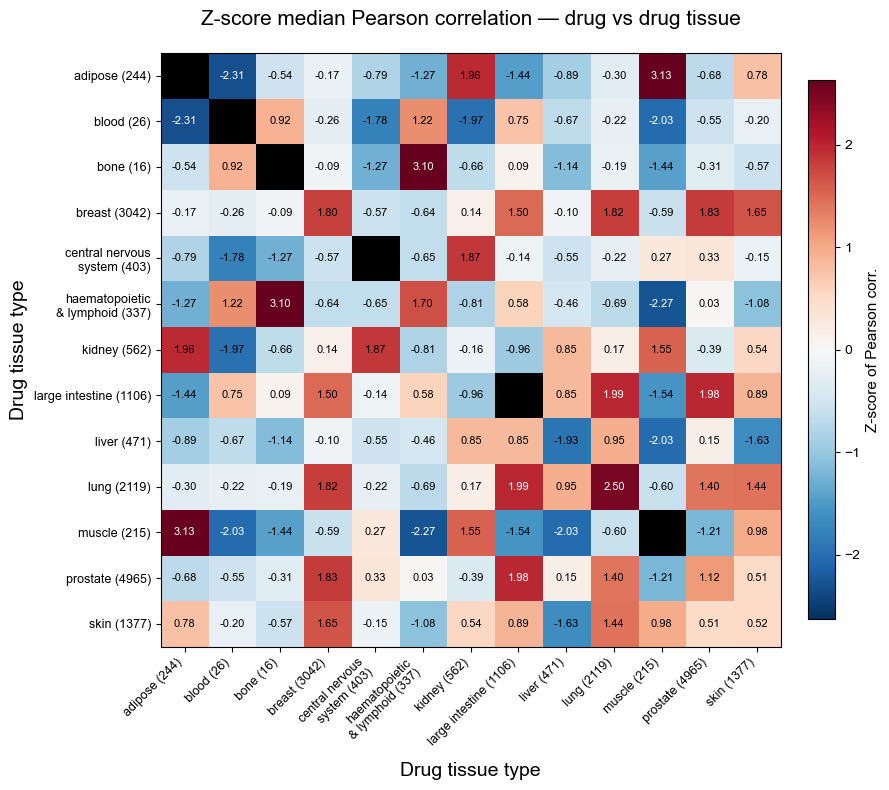

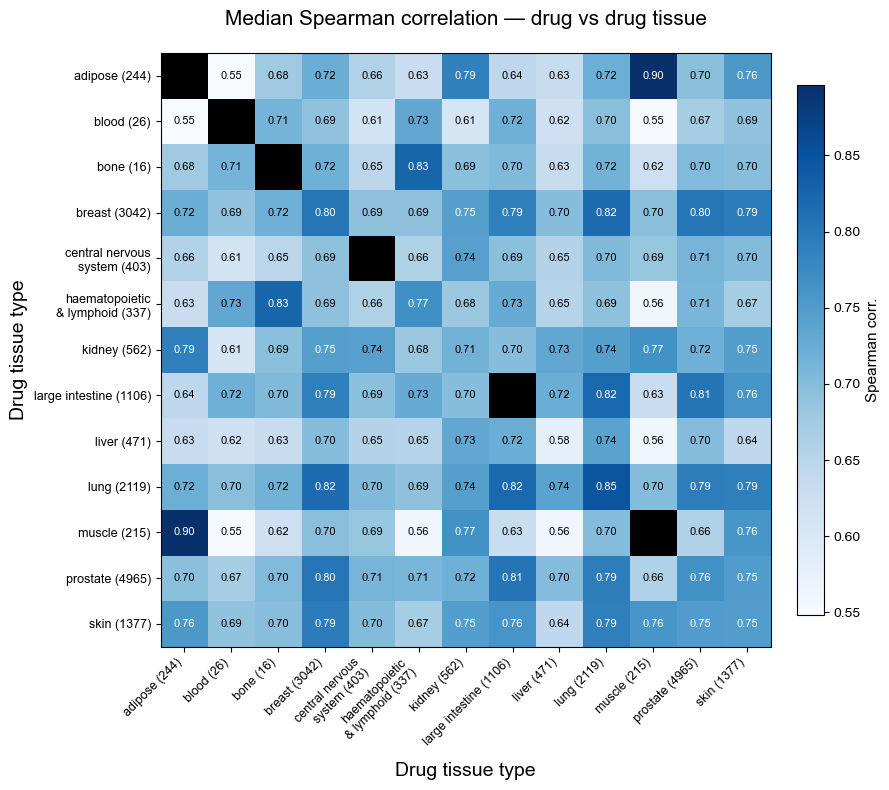

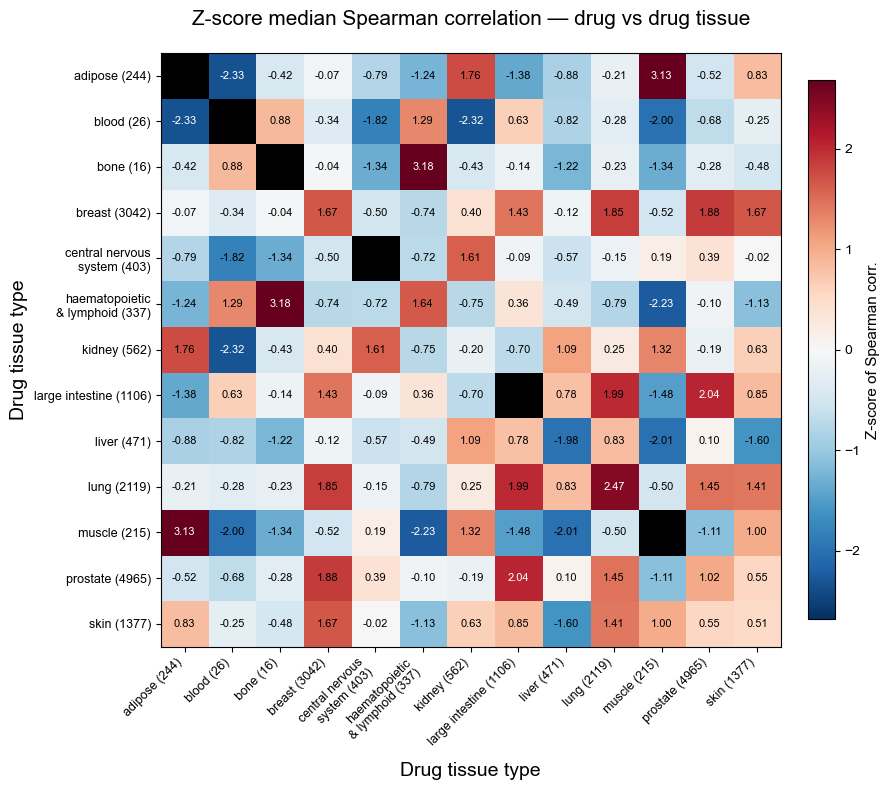

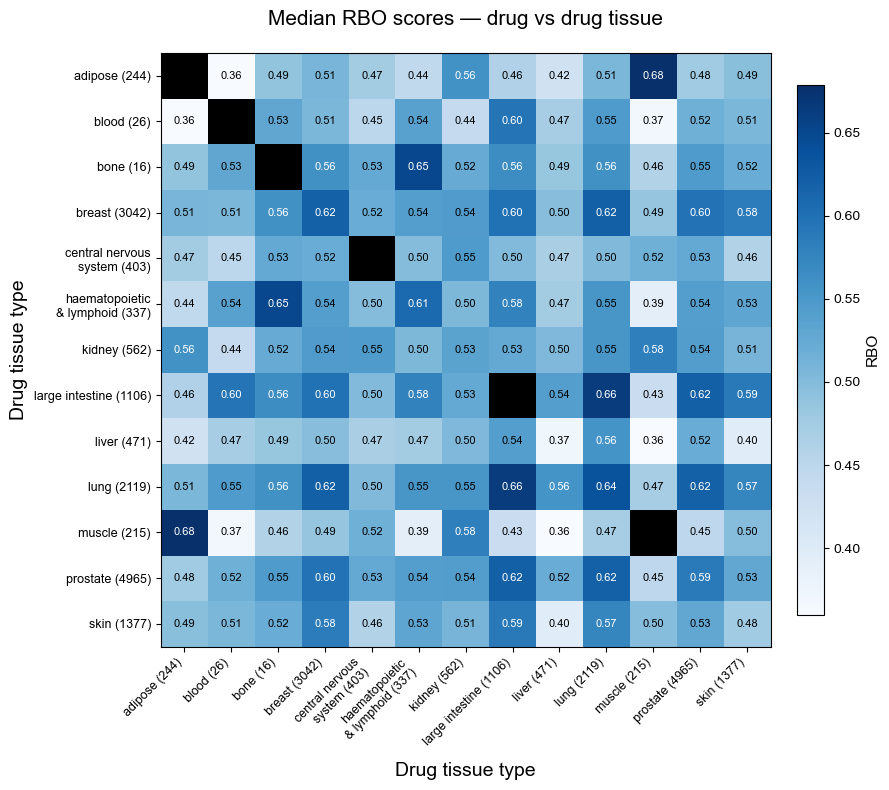

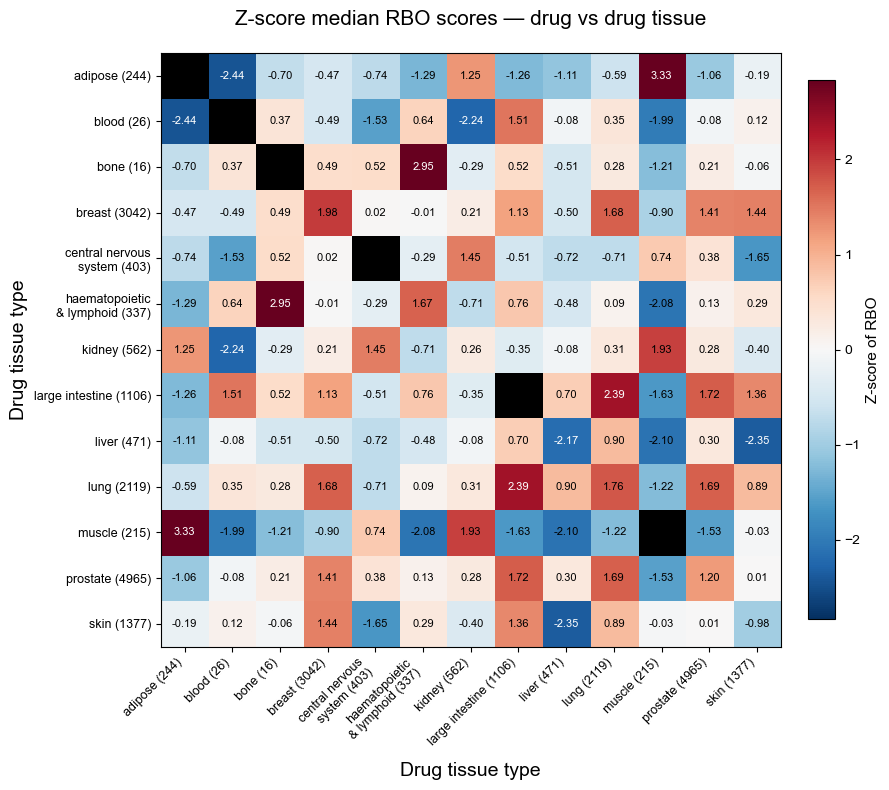

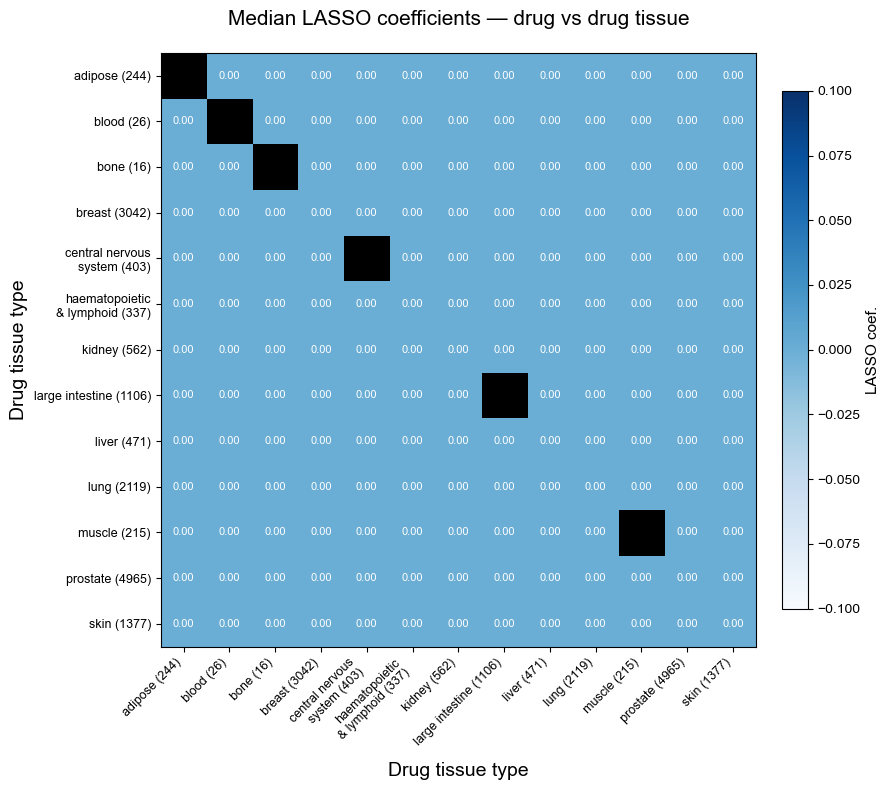

/Users/landon/integrative-drugrep-tb/figures/figureS9/suppl_baseline_functions.py:355: RuntimeWarning: invalid value encountered in divide
  return (matrix - mean) / std
/Users/landon/integrative-drugrep-tb/figures/figureS9/suppl_baseline_functions.py:401: RuntimeWarning: All-NaN slice encountered
  absmax = np.nanmax(np.abs(matrix)) - 0.5


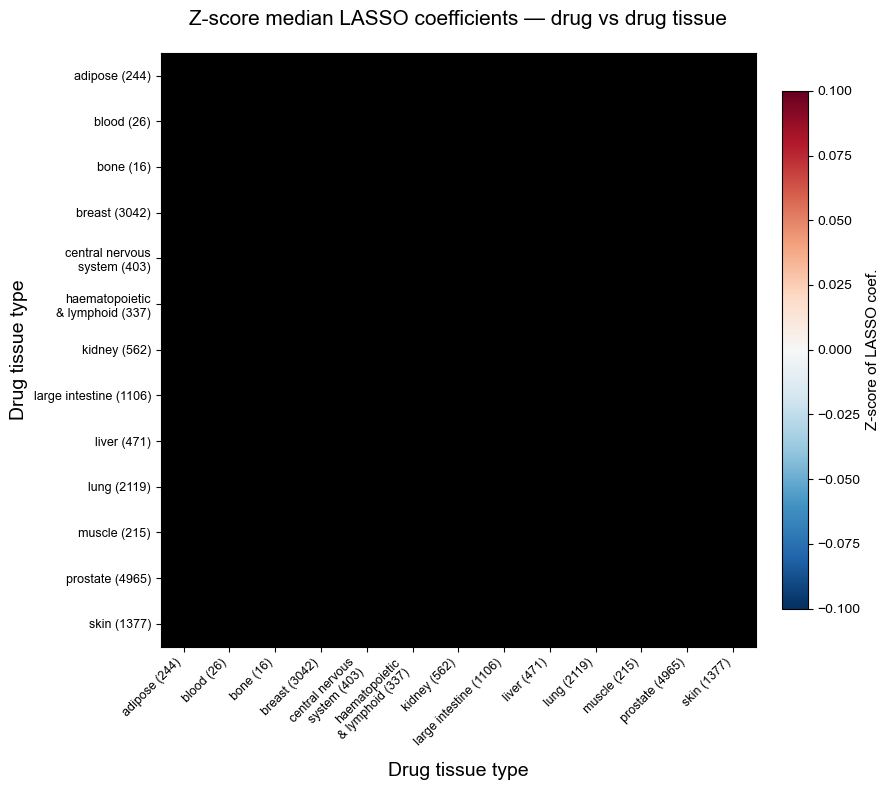

In [5]:
# Build tissue-level matrices and plot 

drug_tissues_trimmed = drug_tissues[1:] # Drop the unknown/-666 tissue

# — Drug × Disease —
for ctype in CORRELATION_TYPES:
    tm = build_tissue_matrix(
        drug_dis_corrs[ctype],
        row_groups=drug_tissue_groups,
        col_groups=disease_tissue_groups,
        mask_diagonal=False,
    )
    # Drop the unknown/-666 tissue
    tm_trimmed = tm.iloc[1:, :]

    xlabels = make_axis_labels(disease_tissues, disease_tissue_groups, DIS_TISSUE_NAME_MAP)
    ylabels = make_axis_labels(drug_tissues_trimmed, drug_tissue_groups, DRUG_TISSUE_NAME_MAP,
                               count_source=drug_tissue_sample_counts)

    plot_tissue_heatmaps(
        tm, xlabels, ylabels,
        title_prefix='drug vs disease tissue',
        xlabel='Disease control tissue',
        ylabel='Drug control tissue',
        corr_type=ctype
    )

# — Drug × Drug —
for ctype in CORRELATION_TYPES:
    tm = build_tissue_matrix(
        drug_drug_corrs[ctype],
        row_groups=drug_tissue_groups,
        col_groups=drug_tissue_groups,
        mask_diagonal=True, # exclude self cell line comparison on diagonal
    )

    # Drop the unknown/-666 tissue
    tm_trimmed = tm.iloc[1:, 1:]

    labels = make_axis_labels(drug_tissues_trimmed, drug_tissue_groups, DRUG_TISSUE_NAME_MAP,
                              count_source=drug_tissue_sample_counts)

    plot_tissue_heatmaps(
        tm_trimmed, labels, labels,
        title_prefix='drug vs drug tissue',
        xlabel='Drug tissue type',
        ylabel='Drug tissue type',
        corr_type=ctype
    )